# SAE Training on Federated Learning Checkpoints

In [1]:
# Cell 1: Environment Bootstrap
import os
REPO_URL = "https://github.com/ha405/FedMI.git"
BRANCH = "cvpr"

if not os.path.exists("FedMI"):
    get_ipython().system(f"git clone -b {BRANCH} {REPO_URL}")
else:
    # Update repo if already exists to get latest fixes
    get_ipython().system(f"cd FedMI && git pull origin {BRANCH}")

os.chdir("FedMI")

from fedmi.env import setup, CHECKPOINT_DIR, DATA_DIR
setup()

# Install dependencies required by the original notebook
%pip install -q einops opencv-python scikit-image overcomplete

Cloning into 'FedMI'...
remote: Enumerating objects: 661, done.
remote: Counting objects: 100% (289/289), done.
remote: Compressing objects: 100% (209/209), done.
remote: Total 661 (delta 118), reused 232 (delta 78), pack-reused 372 (from 1)
Receiving objects: 100% (661/661), 54.60 MiB | 11.61 MiB/s, done.
Resolving deltas: 100% (216/216), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 4.7 MB/s eta 0:00:00


In [49]:
import torch
import torch.nn as nn
from typing import List
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset
import json
import os

import overcomplete
from overcomplete.sae import TopKSAE, JumpSAE, BatchTopKSAE, train_sae
from overcomplete.visualization import show, overlay_top_heatmaps

import sys
# sys.path.append('..') # Original path, now unnecessary as we are in the repo root

from core.config import ExperimentConfig
from core.dataset import get_dataset, get_test_dataloader

class SimpleCNN(nn.Module):
    def __init__(self, conv_channels: List[int] = None, num_classes: int = 10, input_channels: int = 1):
        super(SimpleCNN, self).__init__()
        if conv_channels is None:
            conv_channels = [32, 64, 128]

        self.conv1 = nn.Conv2d(input_channels, conv_channels[0], 3, padding=1)
        self.conv2 = nn.Conv2d(conv_channels[0], conv_channels[1], 3, padding=1)
        self.conv3 = nn.Conv2d(conv_channels[1], conv_channels[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.spatial_dim = 3 if input_channels == 1 else 4
        self.fc = nn.Linear(conv_channels[2] * self.spatial_dim * self.spatial_dim, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def get_model(config) -> nn.Module:
    in_channels = 1 if config.dataset_name == "MNIST" else 3
    return SimpleCNN(
        conv_channels=config.conv_channels,
        num_classes=5,
        input_channels=in_channels
    ).to(config.device)

def load_config_and_data(config_path):
    with open(config_path, 'r') as f:
        config_dict = json.load(f)
    # Filter out comment keys
    config_dict = {k: v for k, v in config_dict.items() if not k.startswith('_')}
    config = ExperimentConfig(**config_dict)
    # Patch paths for Cloud environment
    config.data_root = DATA_DIR
    _, testset = get_dataset(config)
    test_loader = get_test_dataloader(testset, config)
    return config, testset, test_loader

def load_model_from_checkpoint(config, path):
    model = get_model(config)
    state_dict = torch.load(path, map_location=config.device)
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    return model

def extract_activations(model, dataloader, config):
    model.eval()
    activations = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            x, y = batch
            x = x.to(config.device)
            x = model.pool(torch.relu(model.conv1(x)))
            x = model.pool(torch.relu(model.conv2(x)))
            b, c, h, w = x.shape
            x_flat = rearrange(x, 'b c h w -> (b h w) c')
            activations.append(x_flat.cpu())
            y_rep = y.unsqueeze(1).repeat(1, h*w).reshape(-1)
            labels.append(y_rep.cpu())
    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)
    print("Activation shape:", activations.shape)
    print("Label shape:", labels.shape)
    return activations, labels

In [50]:
def train_jump_sae(activations, scenario_name, config):
    subset_size = min(10000, len(activations))
    activations_subset = activations[:subset_size]
    dataset = TensorDataset(activations_subset.to(config.device))
    dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

    print(f"\n--- Training JumpReLU SAE for {scenario_name} ---")
    print(f"Using {subset_size} samples of size {activations.shape[-1]} for SAE training.")

    num_features = activations.shape[-1]
    sae_jump = JumpSAE(num_features, nb_concepts=num_features * 4, bandwidth=1e-2, kernel='silverman', device=config.device)
    optimizer_jump = torch.optim.Adam(sae_jump.parameters(), lr=3e-3)

    desired_sparsity = 0.10

    def criterion_jump(x, x_hat, pre_codes, codes, dictionary):
        loss = (x - x_hat).square().mean()
        sparsity = (codes > 0).float().mean().detach()
        if sparsity > desired_sparsity:
            loss -= sae_jump.thresholds.sum()
        return loss

    logs_jump = train_sae(sae_jump, dataloader, criterion_jump, optimizer_jump, nb_epochs=10, device=config.device)

    print(f"JumpReLU SAE training completed for {scenario_name}.")
    return sae_jump

## IID Experiment

In [51]:
config_iid, testset_iid, test_loader_iid = load_config_and_data('/content/config.json')

# Load IID model - Adjusting path relative to CHECKPOINT_DIR
IID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'iid_experiment/checkpoints/checkpoint_round_5.pt')
if not os.path.exists(IID_CHECKPOINT):
    print(f"Checking fallback path for IID...")
    IID_CHECKPOINT = r"/content/iid1.pt"

if os.path.exists(IID_CHECKPOINT):
    model_iid = load_model_from_checkpoint(config_iid, IID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_iid, labels_iid = extract_activations(model_iid, test_loader_iid, config_iid)
    print(f"IID Activations shape: {activations_iid.shape}")
    # Train JumpReLU SAE
    sae_iid = train_jump_sae(activations_iid, "IID", config_iid)
else:
    print(f"\u26a0\ufe0f IID checkpoint not found at {IID_CHECKPOINT}. Ensure experiments have been run.")

Checking fallback path for IID...
Activation shape: torch.Size([251811, 64])
Label shape: torch.Size([251811])
IID Activations shape: torch.Size([251811, 64])

--- Training JumpReLU SAE for IID ---
Using 10000 samples of size 64 for SAE training.
Epoch[1/10], Loss: 761.8433, R2: 0.5785, L0: 90.3232, Dead Features: 0.8%, Time: 0.1101 seconds
Epoch[2/10], Loss: 745.3756, R2: 0.9177, L0: 69.6587, Dead Features: 19.5%, Time: 0.1031 seconds
Epoch[3/10], Loss: 729.7595, R2: 0.9531, L0: 70.5936, Dead Features: 25.4%, Time: 0.1016 seconds
Epoch[4/10], Loss: 714.2416, R2: 0.9680, L0: 72.8970, Dead Features: 26.2%, Time: 0.1068 seconds
Epoch[5/10], Loss: 698.7711, R2: 0.9758, L0: 73.7293, Dead Features: 27.0%, Time: 0.1104 seconds
Epoch[6/10], Loss: 683.3263, R2: 0.9810, L0: 74.6626, Dead Features: 27.3%, Time: 0.1103 seconds
Epoch[7/10], Loss: 667.8984, R2: 0.9846, L0: 75.3335, Dead Features: 27.3%, Time: 0.0998 seconds
Epoch[8/10], Loss: 652.4822, R2: 0.9872, L0: 75.0874, Dead Features: 28.1%,

## Non-IID Experiment

In [52]:
config_niid, testset_niid, test_loader_niid = load_config_and_data('/content/config.json')

# Load Non-IID model - Adjusting path relative to CHECKPOINT_DIR
NIID_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'niid_experiment/checkpoints/checkpoint_round_10.pt')
if not os.path.exists(NIID_CHECKPOINT):
    print(f"Checking fallback path for NIID...")
    NIID_CHECKPOINT = '/content/noniid1.pt'

if os.path.exists(NIID_CHECKPOINT):
    model_niid = load_model_from_checkpoint(config_niid, NIID_CHECKPOINT)
    # Extract activations from 2nd layer
    activations_niid, labels_niid = extract_activations(model_niid, test_loader_niid, config_niid)
    print(f"Non-IID Activations shape: {activations_niid.shape}")
    # Train JumpReLU SAE
    sae_niid = train_jump_sae(activations_niid, "Non-IID", config_niid)
else:
    print(f"\u26a0\ufe0f Non-IID checkpoint not found at {NIID_CHECKPOINT}.")

Checking fallback path for NIID...
Activation shape: torch.Size([251811, 64])
Label shape: torch.Size([251811])
Non-IID Activations shape: torch.Size([251811, 64])

--- Training JumpReLU SAE for Non-IID ---
Using 10000 samples of size 64 for SAE training.
Epoch[1/10], Loss: 763.3677, R2: 0.5015, L0: 86.1163, Dead Features: 3.9%, Time: 0.1059 seconds
Epoch[2/10], Loss: 745.0605, R2: 0.9303, L0: 69.0228, Dead Features: 32.8%, Time: 0.1025 seconds
Epoch[3/10], Loss: 728.9521, R2: 0.9601, L0: 66.9400, Dead Features: 37.1%, Time: 0.1012 seconds
Epoch[4/10], Loss: 713.0847, R2: 0.9719, L0: 68.6233, Dead Features: 38.7%, Time: 0.1037 seconds
Epoch[5/10], Loss: 697.3561, R2: 0.9781, L0: 69.9268, Dead Features: 38.7%, Time: 0.1028 seconds
Epoch[6/10], Loss: 681.7100, R2: 0.9820, L0: 70.5852, Dead Features: 39.1%, Time: 0.1050 seconds
Epoch[7/10], Loss: 666.1175, R2: 0.9846, L0: 70.7657, Dead Features: 39.5%, Time: 0.1017 seconds
Epoch[8/10], Loss: 650.5619, R2: 0.9866, L0: 70.7092, Dead Feature


SAE GEOMETRY ANALYSIS START

IID activation shape: torch.Size([251811, 64])
Non-IID activation shape: torch.Size([251811, 64])

[1] Extracting dictionary feature directions
IID dictionary: torch.Size([256, 64])
Non-IID dictionary: torch.Size([256, 64])

[2] Cross-model feature similarity
Mean max similarity: 0.3528408408164978
Median max similarity: 0.34554651379585266


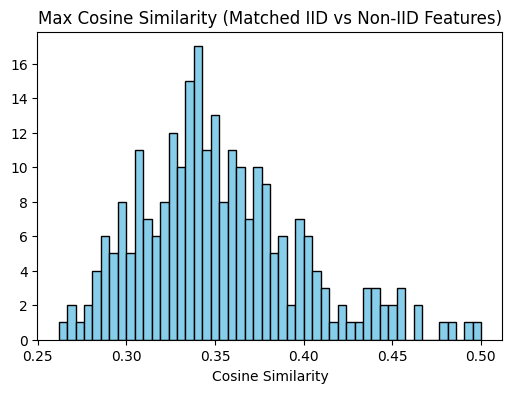


[3] Internal feature geometry
IID mean pairwise similarity: 0.0020990155
Non-IID mean pairwise similarity: 0.0013218301


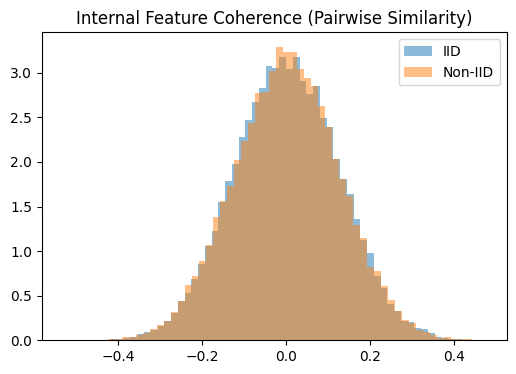


[4] PCA geometry


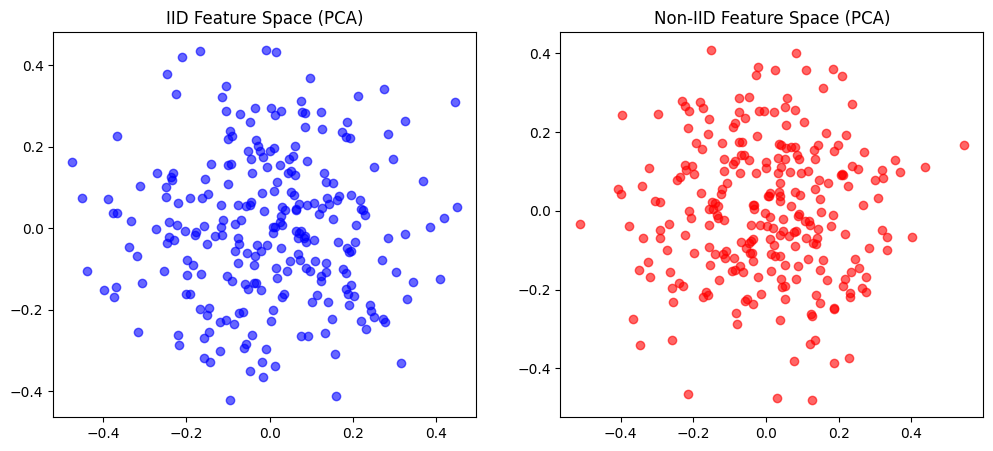


[5] Computing SAE feature activations
IID active feature fraction: 0.3234314024448395
Non-IID active feature fraction: 0.3317823112010956

[6] Feature entropy
IID Normalized Feature Entropy: 0.8403
Non-IID Normalized Feature Entropy: 0.8514
(High entropy = model uses features uniformly; Low = model relies on very few features)

[7] Per-Class Projection: Non-IID activations onto IID features
Class 0 | Mean Projection: 0.9073 | Strongest IID Feature: 86 (val: 7.3221)
Class 1 | Mean Projection: 0.4843 | Strongest IID Feature: 198 (val: 3.7998)
Class 2 | Mean Projection: 0.8225 | Strongest IID Feature: 86 (val: 6.4643)
Class 3 | Mean Projection: 0.8117 | Strongest IID Feature: 86 (val: 6.3363)
Class 4 | Mean Projection: 0.7071 | Strongest IID Feature: 86 (val: 5.6754)

[8] Feature similarity heatmaps


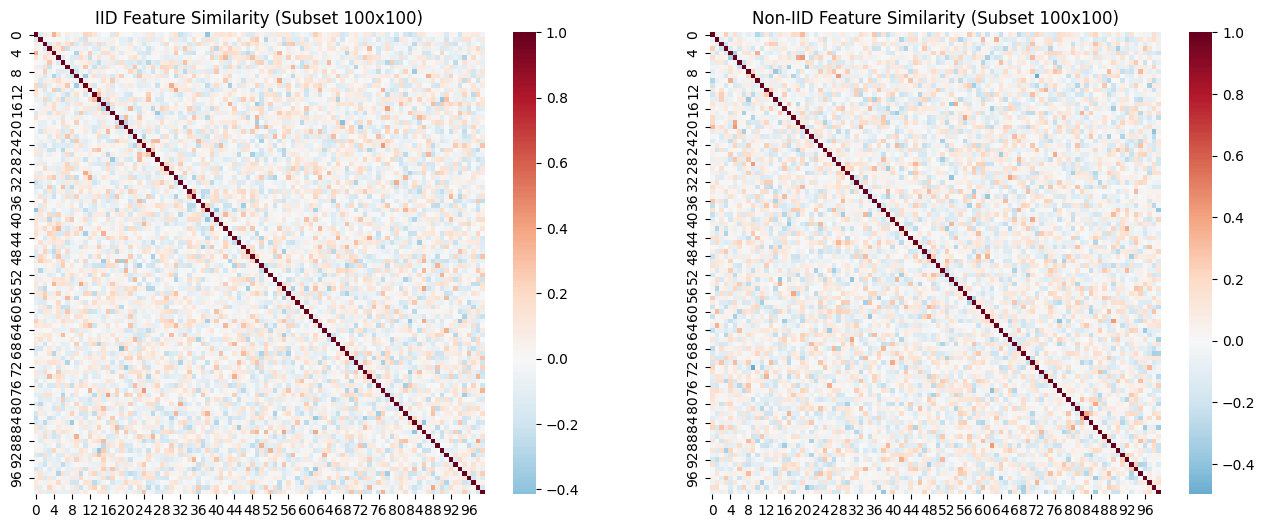


ANALYSIS COMPLETE


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("\n==============================")
print("SAE GEOMETRY ANALYSIS START")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sae_iid = sae_iid.to(device)
sae_niid = sae_niid.to(device)

# Ensure data is on CPU for sklearn/numpy but keep tensors for torch operations
acts_iid_t = torch.as_tensor(activations_iid).float()
acts_niid_t = torch.as_tensor(activations_niid).float()
labs_iid_np = np.array(labels_iid)
labs_niid_np = np.array(labels_niid)

print("IID activation shape:", acts_iid_t.shape)
print("Non-IID activation shape:", acts_niid_t.shape)

# --------------------------------------------------
# 1. Extract dictionary feature vectors
# --------------------------------------------------
print("\n[1] Extracting dictionary feature directions")

# Dict shape: [nb_concepts, d_model]
D_iid = sae_iid.dictionary._weights.detach().cpu()
D_niid = sae_niid.dictionary._weights.detach().cpu()

# Normalize directions to unit sphere for cosine similarity
D_iid_norm = torch.nn.functional.normalize(D_iid, dim=1)
D_niid_norm = torch.nn.functional.normalize(D_niid, dim=1)

print("IID dictionary:", D_iid.shape)
print("Non-IID dictionary:", D_niid.shape)

# --------------------------------------------------
# 2. Cross-model feature similarity
# --------------------------------------------------
print("\n[2] Cross-model feature similarity")

sim_matrix = torch.matmul(D_iid_norm, D_niid_norm.T)
max_sim = sim_matrix.max(dim=1).values

print("Mean max similarity:", max_sim.mean().item())
print("Median max similarity:", max_sim.median().item())

plt.figure(figsize=(6,4))
plt.hist(max_sim.numpy(), bins=50, color='skyblue', edgecolor='black')
plt.title("Max Cosine Similarity (Matched IID vs Non-IID Features)")
plt.xlabel("Cosine Similarity")
plt.show()

# --------------------------------------------------
# 3. Internal feature geometry
# --------------------------------------------------
print("\n[3] Internal feature geometry")

sim_iid = torch.matmul(D_iid_norm, D_iid_norm.T)
sim_niid = torch.matmul(D_niid_norm, D_niid_norm.T)

# Mask diagonal to compare features to others
mask = ~torch.eye(sim_iid.shape[0], dtype=bool)
iid_vals = sim_iid[mask].numpy()
niid_vals = sim_niid[mask].numpy()

print("IID mean pairwise similarity:", iid_vals.mean())
print("Non-IID mean pairwise similarity:", niid_vals.mean())

plt.figure(figsize=(6,4))
plt.hist(iid_vals, bins=60, alpha=0.5, label="IID", density=True)
plt.hist(niid_vals, bins=60, alpha=0.5, label="Non-IID", density=True)
plt.legend()
plt.title("Internal Feature Coherence (Pairwise Similarity)")
plt.show()

# --------------------------------------------------
# 4. PCA visualization
# --------------------------------------------------
print("\n[4] PCA geometry")

pca = PCA(n_components=2)
p_iid = pca.fit_transform(D_iid.numpy())
p_niid = pca.fit_transform(D_niid.numpy())

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].scatter(p_iid[:,0], p_iid[:,1], alpha=0.6, c='blue')
ax[0].set_title("IID Feature Space (PCA)")
ax[1].scatter(p_niid[:,0], p_niid[:,1], alpha=0.6, c='red')
ax[1].set_title("Non-IID Feature Space (PCA)")
plt.show()

# --------------------------------------------------
# 5. Encode activations through SAE
# --------------------------------------------------
print("\n[5] Computing SAE feature activations")

def encode_features(sae, activations):
    x = activations.to(device)
    with torch.no_grad():
        z = sae.encode(x)
    if isinstance(z, tuple): z = z[0]
    return z.detach().cpu()

f_iid = encode_features(sae_iid, acts_iid_t)
f_niid = encode_features(sae_niid, acts_niid_t)

print("IID active feature fraction:", (f_iid > 0).float().mean().item())
print("Non-IID active feature fraction:", (f_niid > 0).float().mean().item())

# --------------------------------------------------
# 6. Feature utilization entropy
# --------------------------------------------------
print("\n[6] Feature entropy")

def feature_entropy(features):
    # Calculate how often each feature is used (probability distribution over features)
    usage = (features > 0).float().sum(0)
    p = usage / (usage.sum() + 1e-8)
    # Shannon Entropy: -sum(p * log p)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    # Normalized Entropy (0 to 1)
    max_entropy = np.log(features.shape[1])
    return entropy / max_entropy

ent_iid = feature_entropy(f_iid)
ent_niid = feature_entropy(f_niid)

print(f"IID Normalized Feature Entropy: {ent_iid.item():.4f}")
print(f"Non-IID Normalized Feature Entropy: {ent_niid.item():.4f}")
print("(High entropy = model uses features uniformly; Low = model relies on very few features)")

# --------------------------------------------------
# 7. Buried knowledge test (Per-Class Projection)
# --------------------------------------------------
print("\n[7] Per-Class Projection: Non-IID activations onto IID features")

# Project Non-IID raw activations onto the IID dictionary directions
# This tells us: "Do the Non-IID activations contain the concepts learned by the IID model?"
proj_niid_on_iid = acts_niid_t @ D_iid_norm.T

classes = np.unique(labs_niid_np)
per_class_stats = {}

for cls in classes:
    mask = (labs_niid_np == cls)
    if not np.any(mask): continue

    cls_projections = proj_niid_on_iid[mask]
    avg_proj = cls_projections.mean().item()
    max_feat_val, max_feat_idx = cls_projections.mean(0).max(0)

    per_class_stats[cls] = {'avg': avg_proj, 'top_feat': max_feat_idx.item(), 'top_val': max_feat_val.item()}
    print(f"Class {int(cls)} | Mean Projection: {avg_proj:.4f} | Strongest IID Feature: {max_feat_idx.item()} (val: {max_feat_val.item():.4f})")

# --------------------------------------------------
# 8. Similarity heatmaps
# --------------------------------------------------
print("\n[8] Feature similarity heatmaps")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(sim_iid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[0])
ax[0].set_title("IID Feature Similarity (Subset 100x100)")
sns.heatmap(sim_niid.numpy()[:100, :100], cmap="RdBu_r", center=0, ax=ax[1])
ax[1].set_title("Non-IID Feature Similarity (Subset 100x100)")
plt.show()

print("\n==============================")
print("ANALYSIS COMPLETE")
print("==============================")

In [ ]:
from fedmi.env import show_images
show_images()

## Download Results

In [ ]:
import shutil
from IPython.display import FileLink

if os.path.isdir(CHECKPOINT_DIR):
    output_zip = "sae_experiment_results.zip"
    shutil.make_archive(output_zip.replace('.zip', ''), 'zip', CHECKPOINT_DIR)
    print(f"Results zipped to {output_zip}")
    display(FileLink(output_zip))
else:
    print("⚠ No results found in checkpoint directory.")


UNIVERSAL SAE (USAE) TRAINING

Training Universal SAE with 256 shared concepts (TopK=12)...
Epoch 01/100 - Total Universal Loss: 835.8305
Epoch 05/100 - Total Universal Loss: 633.7414
Epoch 10/100 - Total Universal Loss: 412.6172
Epoch 15/100 - Total Universal Loss: 286.0641
Epoch 20/100 - Total Universal Loss: 223.2492
Epoch 25/100 - Total Universal Loss: 192.4777
Epoch 30/100 - Total Universal Loss: 174.9356
Epoch 35/100 - Total Universal Loss: 164.1622
Epoch 40/100 - Total Universal Loss: 155.8942
Epoch 45/100 - Total Universal Loss: 149.8987
Epoch 50/100 - Total Universal Loss: 147.6997
Epoch 55/100 - Total Universal Loss: 143.6526
Epoch 60/100 - Total Universal Loss: 138.3281
Epoch 65/100 - Total Universal Loss: 136.0209
Epoch 70/100 - Total Universal Loss: 131.9823
Epoch 75/100 - Total Universal Loss: 130.4473
Epoch 80/100 - Total Universal Loss: 128.9541
Epoch 85/100 - Total Universal Loss: 128.3043
Epoch 90/100 - Total Universal Loss: 127.5856
Epoch 95/100 - Total Universal Lo

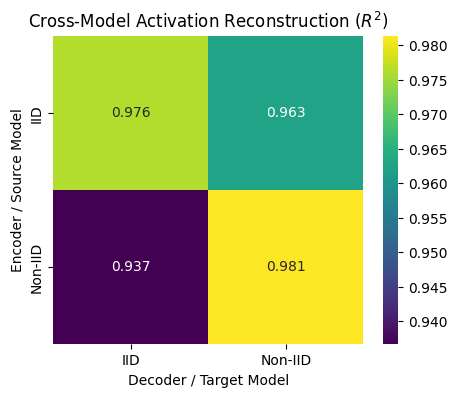

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import DataLoader, TensorDataset

# --- ADDED MISSING IMPORTS ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# -----------------------------

print("\n==============================")
print("UNIVERSAL SAE (USAE) TRAINING")
print("==============================\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# 1. Define the Universal SAE Architecture
# --------------------------------------------------
class UniversalSAE(nn.Module):
    """
    Universal Sparse Autoencoder (USAE) as described in the paper.
    Learns a shared concept space Z across M different models.
    """
    def __init__(self, num_models, input_dim, num_concepts, top_k=32):
        super().__init__()
        self.num_models = num_models
        self.input_dim = input_dim
        self.num_concepts = num_concepts
        self.top_k = top_k

        # M Encoders
        self.W_enc = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim, num_concepts) / (input_dim**0.5))
            for _ in range(num_models)
        ])
        self.b_pre = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_models)
        ])

        # Batch Norm per model (following Appendix A.1)
        self.bn = nn.ModuleList([
            nn.BatchNorm1d(num_concepts)
            for _ in range(num_models)
        ])

        # M Decoders
        self.D = nn.ParameterList([
            nn.Parameter(torch.randn(num_concepts, input_dim) / (num_concepts**0.5))
            for _ in range(num_models)
        ])

    def encode(self, x, model_idx):
        # Apply pre-bias and encode
        h = (x - self.b_pre[model_idx]) @ self.W_enc[model_idx]
        # BatchNorm and ReLU (as per Appendix A.1)
        h = F.relu(self.bn[model_idx](h))

        # TopK Sparsity Enforcement
        top_vals, top_idx = torch.topk(h, self.top_k, dim=-1)
        z = torch.zeros_like(h)
        z.scatter_(-1, top_idx, top_vals)
        return z

    def decode(self, z, model_idx):
        return z @ self.D[model_idx]


# --------------------------------------------------
# 2. Data Preparation
# --------------------------------------------------
# Use the aligned activations from the IID and Non-IID models
min_size = min(len(activations_iid), len(activations_niid))

# Subsample to speed up notebook execution if necessary, keeping aligned indices
subset_size = min(10000, min_size)
A_iid_t = activations_iid[:subset_size].to(device)
A_niid_t = activations_niid[:subset_size].to(device)

dataset = TensorDataset(A_iid_t, A_niid_t)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True)

# --------------------------------------------------
# 3. Hyperparameters & Initialization
# --------------------------------------------------
input_dim = A_iid_t.shape[-1]
expansion_factor = 4 # Using 4x overcomplete for demonstration
num_concepts = input_dim * expansion_factor
top_k = int(num_concepts * 0.05) # Enforce 5% sparsity

usae = UniversalSAE(
    num_models=2,
    input_dim=input_dim,
    num_concepts=num_concepts,
    top_k=top_k
).to(device)

# Following Section 3.2: We initialize independent optimizers for each model's encoder-decoder pair
optimizers = [
    torch.optim.Adam([
        usae.W_enc[i], usae.b_pre[i], usae.bn[i].weight, usae.bn[i].bias, usae.D[i]
    ], lr=1e-3)
    for i in range(2)
]

# --------------------------------------------------
# 4. Universal Training Loop (Figure 3)
# --------------------------------------------------
num_epochs = 100
print(f"Training Universal SAE with {num_concepts} shared concepts (TopK={top_k})...")

usae.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch in dataloader:
        # A_batch[0] is IID, A_batch[1] is Non-IID
        A_batch = batch

        # 1. Select random model to encode this iteration
        i = random.randint(0, usae.num_models - 1)

        # Zero gradients for ALL optimizers
        for opt in optimizers:
            opt.zero_grad()

        # 2. Encode to universal shared space using model i
        Z = usae.encode(A_batch[i], i)

        # 3. Decode for ALL models and aggregate reconstruction loss
        loss = 0.0
        for j in range(usae.num_models):
            A_hat_j = usae.decode(Z, j)
            # Frobenius norm as defined in Equation 6
            loss += torch.norm(A_batch[j] - A_hat_j, p='fro')

        loss.backward()

        # 4. Update ONLY the chosen encoder i and decoder i
        # This implicitly forces cross-model concept alignment!
        optimizers[i].step()

        total_loss += loss.item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{num_epochs} - Total Universal Loss: {total_loss/len(dataloader):.4f}")

print("USAE training completed.")

# --------------------------------------------------
# 5. Validation of Cross-Model Reconstruction (Section 4.2)
# --------------------------------------------------
print("\n[Evaluating Cross-Model Activation Reconstruction (R^2 Score)]")

def calculate_r2(true_A, recon_A):
    ss_res = ((true_A - recon_A)**2).sum()
    ss_tot = ((true_A - true_A.mean(dim=0))**2).sum()
    return max(0.0, (1 - ss_res / ss_tot).item())

usae.eval()
with torch.no_grad():
    # Model 0 = IID, Model 1 = Non-IID
    labels = ["IID", "Non-IID"]
    A_eval = [A_iid_t, A_niid_t]

    # Store R^2 matrix [Encoder_i, Decoder_j]
    r2_matrix = np.zeros((2, 2))

    for i in range(2):
        Z = usae.encode(A_eval[i], i)
        for j in range(2):
            A_hat = usae.decode(Z, j)
            r2_matrix[i, j] = calculate_r2(A_eval[j], A_hat)

    print(f"{'Encoder':<15} | {'Decoder':<15} | R^2 Score")
    print("-" * 45)
    for i in range(2):
        for j in range(2):
            recons_type = "Self-Recon" if i == j else "Cross-Recon"
            print(f"{labels[i]:<15} | {labels[j]:<15} | {r2_matrix[i,j]:.4f} ({recons_type})")

print("\n[Checking Sparsity Level]")

with torch.no_grad():
    Z_iid = usae.encode(A_iid_t, 0)
    Z_niid = usae.encode(A_niid_t, 1)

    iid_active = (Z_iid > 0).float().sum(dim=1).mean().item()
    niid_active = (Z_niid > 0).float().sum(dim=1).mean().item()

print(f"Expected active concepts (TopK): {top_k}")
print(f"IID avg active concepts: {iid_active:.2f}")
print(f"Non-IID avg active concepts: {niid_active:.2f}")

# Visualizing the R2 Matrix (Similar to Figure 5)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(r2_matrix, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Cross-Model Activation Reconstruction ($R^2$)")
ax.set_xlabel("Decoder / Target Model")
ax.set_ylabel("Encoder / Source Model")
plt.show()


CONCEPT UNIVERSALITY & IMPORTANCE ANALYSIS

Total Active Concepts: 234 / 256
Concepts Unique to IID Model: 31
Concepts Unique to Non-IID Model: 20


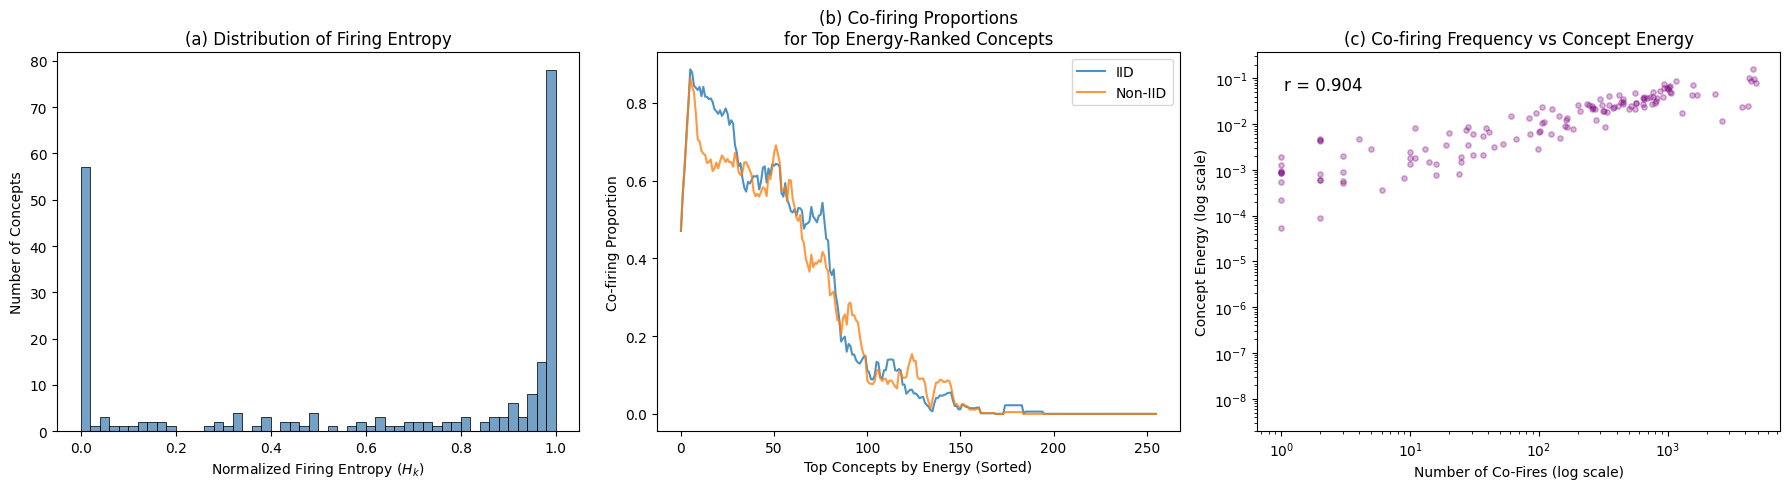

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n==============================")
print("CONCEPT UNIVERSALITY & IMPORTANCE ANALYSIS")
print("==============================\n")

usae.eval()
with torch.no_grad():
    # 1. Encode the same data through both models' USAE encoders
    Z_iid = usae.encode(A_iid_t, 0)   # Model 0 = IID
    Z_niid = usae.encode(A_niid_t, 1) # Model 1 = Non-IID

    # Threshold for firing (tau in Eq 11, we use > 0)
    fires_iid = (Z_iid > 0).float()
    fires_niid = (Z_niid > 0).float()

    # Co-fires (Intersection)
    co_fires = fires_iid * fires_niid

    total_iid = fires_iid.sum(dim=0)
    total_niid = fires_niid.sum(dim=0)
    total_co_fires = co_fires.sum(dim=0)
    total_any_fires = total_iid + total_niid

    # Filter out dead concepts (concepts that never fired)
    active_mask = total_any_fires > 0

    # --------------------------------------------------
    # A. FIRING ENTROPY (Eq 12 & 13 / Fig 6a)
    # --------------------------------------------------
    # Calculate probabilities over ALL concepts to maintain tensor shape
    p_iid = total_iid / (total_any_fires + 1e-9)
    p_niid = total_niid / (total_any_fires + 1e-9)

    # Calculate entropy only for ACTIVE concepts (to plot the histogram accurately)
    p_iid_active = p_iid[active_mask]
    p_niid_active = p_niid[active_mask]

    # log base 2 so max entropy for 2 models is exactly 1.0
    entropy_active = -(p_iid_active * torch.log2(p_iid_active + 1e-9) +
                       p_niid_active * torch.log2(p_niid_active + 1e-9))

    # --------------------------------------------------
    # B. CONCEPT ENERGY / IMPORTANCE (Eq 9)
    # --------------------------------------------------
    def get_concept_energies(Z, decoder_weights):
        expected_Z = Z.mean(dim=0)
        contributions = expected_Z.unsqueeze(1) * decoder_weights
        return torch.norm(contributions, p=2, dim=1)**2

    energy_iid = get_concept_energies(Z_iid, usae.D[0])
    energy_niid = get_concept_energies(Z_niid, usae.D[1])
    avg_energy = (energy_iid + energy_niid) / 2.0

    # --------------------------------------------------
    # C. CO-FIRE PROPORTION (Eq 14 / Fig 6b)
    # --------------------------------------------------
    cfp_iid = total_co_fires / (total_iid + 1e-9)
    cfp_niid = total_co_fires / (total_niid + 1e-9)

    # Sort concepts by average energy (descending)
    sorted_indices = torch.argsort(avg_energy, descending=True)
    top_k_plot = min(1000, len(sorted_indices))

    sorted_cfp_iid = cfp_iid[sorted_indices][:top_k_plot].cpu().numpy()
    sorted_cfp_niid = cfp_niid[sorted_indices][:top_k_plot].cpu().numpy()

    # --------------------------------------------------
    # D. FINDING UNIQUE CONCEPTS (Section 4.6)
    # --------------------------------------------------
    # Both total_iid and p_iid now have the exact same shape!
    unique_to_iid = torch.where((total_iid > 10) & (p_iid > 0.95))[0]
    unique_to_niid = torch.where((total_niid > 10) & (p_niid > 0.95))[0]

    print(f"Total Active Concepts: {active_mask.sum().item()} / {Z_iid.shape[1]}")
    print(f"Concepts Unique to IID Model: {len(unique_to_iid)}")
    print(f"Concepts Unique to Non-IID Model: {len(unique_to_niid)}")

# --------------------------------------------------
# E. PLOTTING (Replicating Figure 6)
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Firing Entropy Histogram (Fig 6a)
sns.histplot(entropy_active.cpu().numpy(), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title("(a) Distribution of Firing Entropy")
axes[0].set_xlabel("Normalized Firing Entropy ($H_k$)")
axes[0].set_ylabel("Number of Concepts")
axes[0].set_xlim(-0.05, 1.05)

# Plot 2: Co-Firing Proportions (Fig 6b)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    return np.convolve(y, box, mode='same')

axes[1].plot(smooth(sorted_cfp_iid, 10), label='IID', alpha=0.8)
axes[1].plot(smooth(sorted_cfp_niid, 10), label='Non-IID', alpha=0.8)
axes[1].set_title("(b) Co-firing Proportions\nfor Top Energy-Ranked Concepts")
axes[1].set_xlabel("Top Concepts by Energy (Sorted)")
axes[1].set_ylabel("Co-firing Proportion")
axes[1].legend()

# Plot 3: Co-fires vs Energy (Fig 6c)
x_data = total_co_fires[active_mask].cpu().numpy()
y_data = avg_energy[active_mask].cpu().numpy()

axes[2].scatter(x_data, y_data, alpha=0.3, s=15, color='purple')
axes[2].set_title("(c) Co-firing Frequency vs Concept Energy")
axes[2].set_xlabel("Number of Co-Fires (log scale)")
axes[2].set_ylabel("Concept Energy (log scale)")
axes[2].set_xscale('log')
axes[2].set_yscale('log')

# Calculate correlation (Pearson on log-log space)
valid = (x_data > 0) & (y_data > 0)
if valid.sum() > 1:
    r = np.corrcoef(np.log10(x_data[valid]), np.log10(y_data[valid]))[0, 1]
    axes[2].text(0.05, 0.9, f"r = {r:.3f}", transform=axes[2].transAxes, fontsize=12,
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

In [55]:
print("\n[Checking Concept Dictionary Alignment]")

with torch.no_grad():

    # Encoder matrices
    W0 = usae.W_enc[0]   # (input_dim, num_concepts)
    W1 = usae.W_enc[1]

    # Transpose so each row = concept vector
    W0 = W0.T
    W1 = W1.T

    # Normalize concept vectors
    W0 = F.normalize(W0, dim=1)
    W1 = F.normalize(W1, dim=1)

    # Cosine similarity between all concept pairs
    sim_matrix = W0 @ W1.T   # (num_concepts × num_concepts)

    # For each concept in model 0, find best matching concept in model 1
    max_sim_0 = sim_matrix.max(dim=1).values

    # For each concept in model 1, find best matching concept in model 0
    max_sim_1 = sim_matrix.max(dim=0).values

    avg_alignment = (max_sim_0.mean() + max_sim_1.mean()) / 2

print(f"Average concept alignment: {avg_alignment.item():.3f}")
print(f"Median alignment: {torch.median(max_sim_0).item():.3f}")
print(f"Max alignment: {max_sim_0.max().item():.3f}")


[Checking Concept Dictionary Alignment]
Average concept alignment: 0.359
Median alignment: 0.354
Max alignment: 0.494


In [56]:
Z_iid = usae.encode(A_iid_t, 0)
Z_niid = usae.encode(A_niid_t, 1)

cos = F.cosine_similarity(Z_iid, Z_niid, dim=1)
print("Average latent cosine:", cos.mean().item())

Average latent cosine: 0.8132456541061401


In [57]:
import torch
from tqdm import tqdm
from einops import rearrange

print("\n==============================")
print("RECONSTRUCTED PERFORMANCE EVALUATION")
print("==============================\n")

def get_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total

def evaluate_usae_performance(source_idx, target_idx, source_model, target_model, usae, dataloader):
    """
    Passes data through source model up to the USAE layer,
    reconstructs for target model, and finishes the forward pass.
    """
    source_model.eval()
    target_model.eval()
    usae.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            # 1. Source Model partial forward (up to conv2)
            feat = source_model.pool(torch.relu(source_model.conv1(x)))
            feat = source_model.pool(torch.relu(source_model.conv2(feat)))

            b, c, h, w = feat.shape

            # 2. USAE Reconstruction
            # Flatten for USAE: [B, C, H, W] -> [B*H*W, C]
            feat_flat = rearrange(feat, 'b c h w -> (b h w) c')

            # Encode/Decode
            Z = usae.encode(feat_flat, source_idx)
            recon_flat = usae.decode(Z, target_idx)

            # Unflatten back to spatial: [B*H*W, C] -> [B, C, H, W]
            # Added .contiguous() to ensure memory layout is correct
            recon_feat = rearrange(recon_flat, '(b h w) c -> b c h w', b=b, h=h, w=w).contiguous()

            # 3. Target Model partial forward (Conv3 -> FC)
            out = target_model.pool(torch.relu(target_model.conv3(recon_feat)))

            # Changed .view() to .reshape() to fix the RuntimeError
            out = out.reshape(out.size(0), -1)
            logits = target_model.fc(out)

            # 4. Stats
            _, predicted = torch.max(logits.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    return correct / total

# --- RUNNING THE TEST ---

print("Calculating Baselines...")
acc_iid_base = get_accuracy(model_iid, test_loader_iid)
acc_niid_base = get_accuracy(model_niid, test_loader_niid)

print("Calculating USAE Reconstructed Performance...")
# IID -> IID (Self)
acc_iid_self = evaluate_usae_performance(0, 0, model_iid, model_iid, usae, test_loader_iid)
# Non-IID -> Non-IID (Self)
acc_niid_self = evaluate_usae_performance(1, 1, model_niid, model_niid, usae, test_loader_niid)

print("Calculating Cross-Model (Brain Swap) Performance...")
# IID encoded -> Reconstructed as Non-IID -> Non-IID Head
acc_iid_to_niid = evaluate_usae_performance(0, 1, model_iid, model_niid, usae, test_loader_iid)
# Non-IID encoded -> Reconstructed as IID -> IID Head
acc_niid_to_iid = evaluate_usae_performance(1, 0, model_niid, model_iid, usae, test_loader_niid)

print("\n" + "="*50)
print(f"{'Experiment Type':<30} | Accuracy")
print("-" * 50)
print(f"{'Baseline IID':<30} | {acc_iid_base:.4f}")
print(f"{'Baseline Non-IID':<30} | {acc_niid_base:.4f}")
print("-" * 50)
print(f"{'USAE Self-Recon (IID)':<30} | {acc_iid_self:.4f}")
print(f"{'USAE Self-Recon (Non-IID)':<30} | {acc_niid_self:.4f}")
print("-" * 50)
print(f"{'USAE Cross (IID -> Non-IID)':<30} | {acc_iid_to_niid:.4f}")
print(f"{'USAE Cross (Non-IID -> IID)':<30} | {acc_niid_to_iid:.4f}")
print("="*50)


RECONSTRUCTED PERFORMANCE EVALUATION

Calculating Baselines...
Calculating USAE Reconstructed Performance...
Calculating Cross-Model (Brain Swap) Performance...

Experiment Type                | Accuracy
--------------------------------------------------
Baseline IID                   | 0.9728
Baseline Non-IID               | 0.7667
--------------------------------------------------
USAE Self-Recon (IID)          | 0.9693
USAE Self-Recon (Non-IID)      | 0.7675
--------------------------------------------------
USAE Cross (IID -> Non-IID)    | 0.7369
USAE Cross (Non-IID -> IID)    | 0.9632
